<a href="https://colab.research.google.com/github/arthur-cristo/ram-scrap/blob/main/ram_scrap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get update

!apt-get install -y \
    libatk1.0-0 \
    libatk-bridge2.0-0 \
    libcups2 \
    libxkbcommon0 \
    libxcomposite1 \
    libxdamage1 \
    libxfixes3 \
    libxrandr2 \
    libgbm1 \
    libpango-1.0-0 \
    libcairo2 \
    libasound2 \
    libnss3 \
    libxshmfence1

!pip install playwright

!playwright install chromium

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:3 https://cli.github.com/packages stable InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [77.8 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,295 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,070 kB]
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,945 kB]


In [ ]:
import asyncio
import pandas as pd
from bs4 import BeautifulSoup
from playwright.async_api import async_playwright
from urllib.parse import urljoin
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

In [ ]:
BASE_URL = "https://meupc.net"
MEMORIAS_PATH = "/api/memorias"
MAX_ITENS = 200

In [ ]:
async def obter_csrf_token(context, page):
    """Acessa a página principal para capturar o cookie de segurança."""
    print("🌐 Acessando site para obter token CSRF...")
    await page.goto(f"{BASE_URL}/memorias", wait_until="networkidle")
    cookies = await context.cookies()
    for cookie in cookies:
        if cookie["name"] == "ci_csrf_cookie":
            return cookie["value"]
    return None

async def buscar_pagina_memorias(page, csrf_token, url_base, page_num):
    """Faz a requisição POST para buscar a lista de peças de uma página específica."""
    return await page.evaluate(
        """
        async ({ pageNum, csrfToken, url }) => {
            const formData = new FormData();
            formData.append("ci_csrf_token", csrfToken);

            const fetchUrl = `${url}&page=${pageNum}`;

            const response = await fetch(fetchUrl, {
                method: "POST",
                body: formData,
                credentials: "include"
            });
            return await response.json();
        }
        """,
        {
            "pageNum": page_num,
            "csrfToken": csrf_token,
            "url": url_base
        }
    )

async def buscar_historico_preco(page, csrf_token, hash_produto):
    """Faz a requisição POST para buscar as datas e valores do histórico."""
    return await page.evaluate(
        """
        async ({ hash, csrfToken }) => {
            const formData = new FormData();
            formData.append("ci_csrf_token", csrfToken);

            const response = await fetch(
                `https://meupc.net/api/historico?hash=${hash}&tipo_preco=menor_dia`,
                {
                    method: "POST",
                    body: formData,
                    credentials: "include"
                }
            );
            return await response.json();
        }
        """,
        {
            "hash": hash_produto,
            "csrfToken": csrf_token
        }
    )

# ==========================================
# LÓGICA DE EXTRAÇÃO E PROCESSAMENTO
# ==========================================

async def coletar_dados_por_url(page, csrf_token, url_api_busca):
    """Controla a paginação e a montagem do dicionário de resultados."""
    resultados = []
    hashes_vistos = set()  # VALIDAÇÃO 2: Memória dos itens já processados
    nomes_vistos = set()
    page_num = 0

    while len(resultados) < MAX_ITENS:
        page_num += 1
        print(f"\n📄 PÁGINA {page_num}...")

        try:
            data = await buscar_pagina_memorias(page, csrf_token, url_api_busca, page_num)
        except Exception as e:
            print("❌ Erro ao buscar JSON da página:", e)
            break

        pecas = data.get("peca", [])
        if not pecas:
            print("❌ Nenhuma peça encontrada (fim real da lista).")
            break

        novas_pecas_na_pagina = 0

        for i, peca in enumerate(pecas):
            if len(resultados) >= MAX_ITENS:
                break

            hash_produto = peca.get("hash")
            nome = peca.get("descricao")

            # VALIDAÇÃO 2: Evita loop infinito se a API ficar retornando os mesmos itens no fim da lista
            if hash_produto in hashes_vistos or nome in nomes_vistos:
                continue

            hashes_vistos.add(hash_produto)
            nomes_vistos.add(nome)
            novas_pecas_na_pagina += 1

            if peca.get("patrocinado") == "1":
                continue

            # VALIDAÇÃO 1: Pula itens que não possuem preço definido
            preco_atual = peca.get("preco")
            if not preco_atual or float(preco_atual) == 0:
                print(f"⏭️ Sem preço, ignorado: {nome}")
                continue

            slug = peca.get("slug")

            # Algumas rotas retornam popularidade ou popularidade_percent
            popularidade = peca.get("popularidade") or 0

            memoria = {
                "id": hash_produto,
                "index": len(resultados) + 1,
                "nome": nome,
                "url": f"{BASE_URL}/peca/{hash_produto}/{slug}",
                "preco": preco_atual,
                "preco_pix": peca.get("preco_boleto"),
                "preco_por_gb": peca.get("preco_gb"),
                "modulos": peca.get("modulo"),
                "capacidade": peca.get("tamanho_padrao"),
                "popularidade": popularidade,
            }

            try:
                historico = await buscar_historico_preco(page, csrf_token, hash_produto)
                labels = historico.get("labels", [])
                datasets = historico.get("datasets", [])
                precos_historico = datasets[0].get("data", []) if datasets else []

                for data_label, preco_label in zip(labels, precos_historico):
                    if data_label and preco_label:
                        memoria[data_label] = preco_label

                resultados.append(memoria)
                print(f"💾 SALVO [{len(resultados)}] {nome} | Preço: R${preco_atual} | Pop: {popularidade}%")

            except Exception as e:
                print(f"❌ Erro ao buscar histórico de {nome}:", e)

        # Se passamos por todos os itens da página e nenhum era novo (já estavam no Set), a API está em loop
        if novas_pecas_na_pagina == 0:
            print("⚠️ Fim dos itens únicos alcançado (A API está retornando a última página). Parando busca.")
            break

    return resultados

def processar_e_salvar_dataframe(resultados, nome_arquivo):
    """Aplica filtros de outliers, ordena colunas e exporta o CSV."""
    if not resultados:
        print(f"⚠️ Nenhum dado para salvar em {nome_arquivo}")
        return

    print(f"\n📊 Processando dados para {nome_arquivo}...")
    df = pd.DataFrame(resultados)

    colunas_base = [
        "index", "id", "nome", "url", "preco", "preco_pix",
        "preco_por_gb", "modulos", "capacidade", "popularidade"
    ]
    colunas_datas = sorted([c for c in df.columns if c not in colunas_base])
    df = df[[c for c in colunas_base if c in df.columns] + colunas_datas]

    df["preco_por_gb"] = pd.to_numeric(df["preco_por_gb"], errors="coerce")
    df = df[df["preco_por_gb"].notna()]

    media_preco_gb = df["preco_por_gb"].mean()
    limite_min = media_preco_gb / 2
    limite_max = media_preco_gb * 2
    df = df[(df["preco_por_gb"] >= limite_min) & (df["preco_por_gb"] <= limite_max)]

    if colunas_datas:
        ultima_data = colunas_datas[-1]
        df = df[df[ultima_data].notna()]

    df["index"] = range(1, len(df) + 1)

    df.to_csv(nome_arquivo, sep=";", encoding="utf-8-sig", index=False)
    print(f"✅ Arquivo salvo: {nome_arquivo} ({len(df)} linhas restantes após filtros)")

    try:
        from google.colab import files
        files.download(nome_arquivo)
    except ImportError:
        pass

In [ ]:
async def main():
    # Parâmetros das duas buscas desejadas
    URL_DDR4 = f"{BASE_URL}{MEMORIAS_PATH}?comp=true&vel=4,3200&tam=15,16,17"
    URL_DDR5 = f"{BASE_URL}{MEMORIAS_PATH}?comp=true&vel=11,6000&tam=15,16,17"

    async with async_playwright() as p:
        browser = await p.chromium.launch(
            headless=True,
            args=["--no-sandbox", "--disable-dev-shm-usage"]
        )
        context = await browser.new_context()
        page = await context.new_page()

        csrf_token = await obter_csrf_token(context, page)

        if not csrf_token:
            print("❌ Falha crítica: ci_csrf_cookie não encontrado.")
            await browser.close()
            return

        print("\n" + "="*50)
        print("🚀 INICIANDO RASPAGEM: MEMÓRIAS DDR4")
        print("="*50)
        resultados_ddr4 = await coletar_dados_por_url(page, csrf_token, URL_DDR4)
        processar_e_salvar_dataframe(resultados_ddr4, "memorias_ddr4_historico.csv")

        print("\n" + "="*50)
        print("🚀 INICIANDO RASPAGEM: MEMÓRIAS DDR5")
        print("="*50)
        resultados_ddr5 = await coletar_dados_por_url(page, csrf_token, URL_DDR5)
        processar_e_salvar_dataframe(resultados_ddr5, "memorias_ddr5_historico.csv")

        await browser.close()
        print("\n🏁 Processo completo finalizado com sucesso!")

In [ ]:
await main()

🌐 Acessando site para obter token CSRF...

🚀 INICIANDO RASPAGEM: MEMÓRIAS DDR4

📄 PÁGINA 1...
💾 SALVO [1] Rise Mode Z (Preto) | Preço: R$939.90 | Pop: 4144%
💾 SALVO [2] Rise Mode Diamond Series (Branco) | Preço: R$999.90 | Pop: 3371%
💾 SALVO [3] Husky Impulse (Preto) | Preço: R$890.00 | Pop: 833%
💾 SALVO [4] XPG Spectrix D35G (RGB) | Preço: R$1117.53 | Pop: 336%
💾 SALVO [5] Corsair Vengeance LPX (Preto) | Preço: R$1079.00 | Pop: 239%
💾 SALVO [6] Rise Mode Z Series (Preto) | Preço: R$822.51 | Pop: 221%
💾 SALVO [7] Indilinx Magic I (Preto) | Preço: R$917.64 | Pop: 192%
💾 SALVO [8] Kingston Kingston HyperX Fury (Preto) | Preço: R$935.00 | Pop: 179%
💾 SALVO [9] Kingston Fury Beast RGB (RGB) | Preço: R$1976.46 | Pop: 168%
💾 SALVO [10] XPG GAMMIX D35 (Preto) | Preço: R$1235.20 | Pop: 152%
💾 SALVO [11] Corsair Corsair Vengeance RGB Pro (RGB) | Preço: R$1482.34 | Pop: 116%
💾 SALVO [12] Lexar LD4AU016G-B3200GSST (Preto) | Preço: R$600.00 | Pop: 111%
💾 SALVO [13] Geil Orion (Cinza) | Preço: R$11

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🚀 INICIANDO RASPAGEM: MEMÓRIAS DDR5

📄 PÁGINA 1...
💾 SALVO [1] XPG Lancer Blade RGB (RGB) | Preço: R$1941.10 | Pop: 3047%
💾 SALVO [2] Kingston Fury Beast (Preto) | Preço: R$1964.69 | Pop: 831%
💾 SALVO [3] XPG Lancer Blade (Branco) | Preço: R$1929.40 | Pop: 171%
💾 SALVO [4] Husky Impulse (Preto) | Preço: R$1764.60 | Pop: 151%
💾 SALVO [5] XPG Lancer Blade (Preto) | Preço: R$1974.11 | Pop: 133%
💾 SALVO [6] Corsair Vengeance (Cinza) | Preço: R$1941.16 | Pop: 119%
💾 SALVO [7] Kingston Fury Beast RGB (RGB) | Preço: R$2199.99 | Pop: 88%
💾 SALVO [8] Kingston Fury Beast Expo (Preto) | Preço: R$2282.34 | Pop: 82%
💾 SALVO [9] Rise Mode Zeus Series (Branco) | Preço: R$1990.00 | Pop: 77%
💾 SALVO [10] Kingston Fury Beast Expo (Branco) | Preço: R$2294.11 | Pop: 68%
💾 SALVO [11] Corsair Vengeance RGB (RGB) | Preço: R$2152.93 | Pop: 54%
💾 SALVO [12] ADATA XPG Lancer (Preto) | Preço: R$2352.93 | Pop: 51%
💾 SALVO [13] Pichau Hubble (Preto) | Preço: R$2952.93 | Pop: 49%
💾 SALVO [14] Kingston Fury Beast E

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🏁 Processo completo finalizado com sucesso!


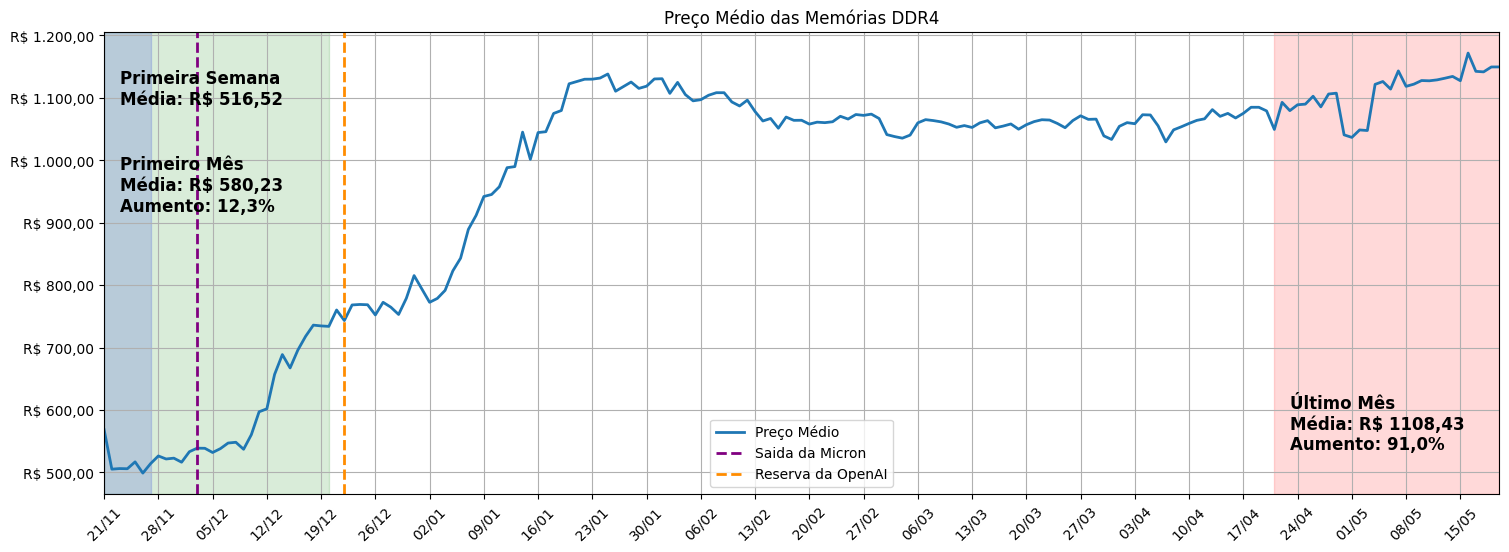

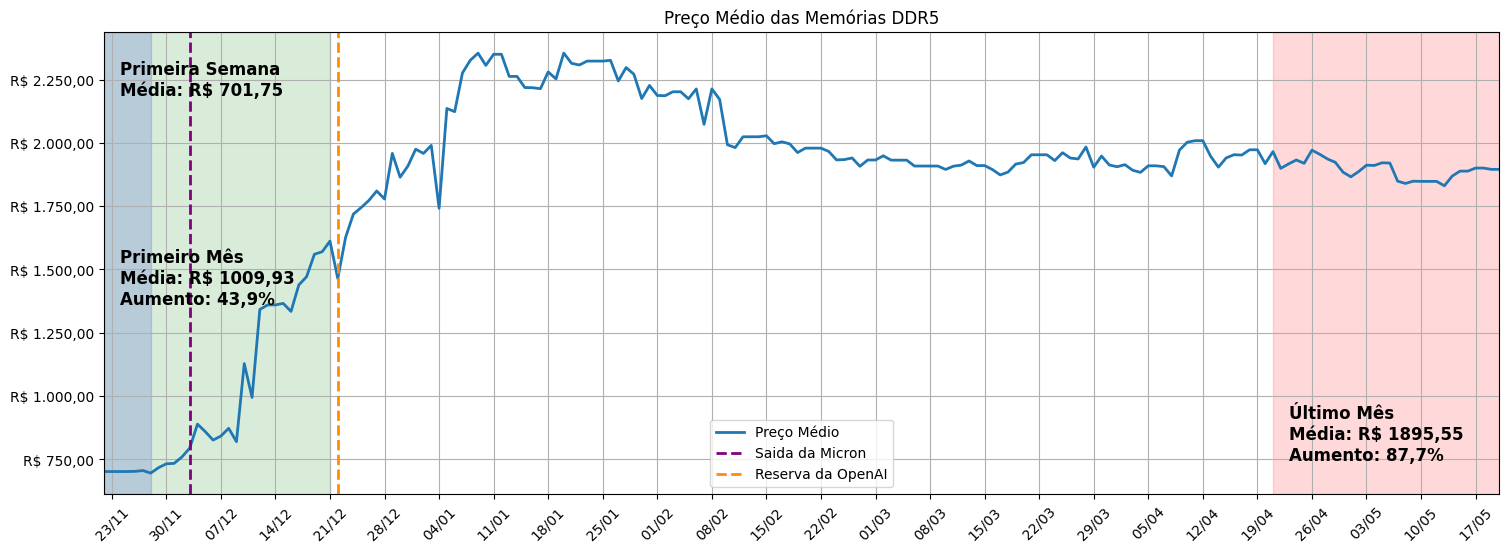

In [ ]:
# =========================
# Ler CSV
# =========================
ddr4_df = pd.read_csv("memorias_ddr4_historico.csv", sep=";")
ddr5_df = pd.read_csv("memorias_ddr5_historico.csv", sep=";")
dfs = [ddr4_df, ddr5_df]
tipos = ["DDR4", "DDR5"]

# =========================
# Processamento e Plot
# =========================
for tipo, df in zip(tipos, dfs):
  date_cols = [col for col in df.columns if col.startswith("202")]

  datas = pd.to_datetime(date_cols)

  # Converter preços para número
  df[date_cols] = df[date_cols].apply(
      pd.to_numeric,
      errors="coerce"
  )

  # =========================
  # Preço médio
  # =========================
  media_precos = df[date_cols].mean()

  # =========================
  # Estatísticas
  # =========================
  primeira_semana_media = media_precos.iloc[:7].mean()
  primeiro_mes_media = media_precos.iloc[:30].mean()
  ultimo_mes_media = media_precos.iloc[-30:].mean()

  aumento_pct_semana = (
      (primeiro_mes_media - primeira_semana_media) / primeira_semana_media
  ) * 100
  aumento_pct_mes = (
      (ultimo_mes_media - primeiro_mes_media)
      / primeiro_mes_media
  ) * 100

  # =========================
  # Plot
  # =========================
  plt.figure(figsize=(18,6))

  plt.plot(
      datas,
      media_precos,
      label="Preço Médio",
      linewidth=2,
  )
  # =========================
  # Fundo colorido
  # =========================

  # Primeira Semana
  plt.axvspan(datas[0], datas[6], color='blue', alpha=0.15)

  # Primeiro mês
  plt.axvspan(
      datas[0],
      datas[29],
      color='green',
      alpha=0.15,
  )

  # Último mês
  plt.axvspan(
      datas[-30],
      datas[-1],
      color='red',
      alpha=0.15,
  )

  # =========================
  # Textos
  # =========================

  y_top = media_precos.max() * 0.93
  y_mid = (y_top + y_bot) / 2
  y_bot = media_precos.min() / 0.93

  # Primeira semana
  plt.text(
      datas[2],
      y_top,
      (
          f"Primeira Semana\n"
          f"Média: R$ {primeira_semana_media:.2f}"
      ).replace(".", ","),
      fontsize=12,
      weight="bold"
  )

  # Primeiro mês
  plt.text(
      datas[2],
      y_mid,
      (
          f"Primeiro Mês\n"
          f"Média: R$ {primeiro_mes_media:.2f}\n"
          f"Aumento: {aumento_pct_semana:.1f}%"
      ).replace(".", ","),
      fontsize=12,
      weight="bold"
  )

  # Último mês
  plt.text(
      datas[-28],
      y_bot,
      (
          f"Último Mês\n"
          f"Média: R$ {ultimo_mes_media:.2f}\n"
          f"Aumento: {aumento_pct_mes:.1f}%"
      ).replace(".", ","),
      fontsize=12,
      weight="bold"
  )

  # =========================
  # Linhas guia
  # =========================
  plt.axvline(
      pd.Timestamp("2025-12-03"),
      linestyle="--",
      linewidth=2,
      color="purple",
      label="Saida da Micron"
  )

  plt.axvline(
      pd.Timestamp("2025-12-22"),
      linestyle="--",
      linewidth=2,
      color="darkorange",
      label="Reserva da OpenAI"
  )

  # =========================
  # Eixo X
  # =========================
  ax = plt.gca()

  ax.xaxis.set_major_locator(
      mdates.DayLocator(interval=7)
  )

  ax.xaxis.set_major_formatter(
      mdates.DateFormatter('%d/%m')
  )

  plt.xticks(rotation=45)

  # =========================
  # Formatação eixo Y
  # =========================
  def formato_reais(x, pos):
      return f"R$ {x:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

  ax.yaxis.set_major_formatter(
      FuncFormatter(formato_reais)
  )

  # =========================
  # Labels
  # =========================
  plt.title(f"Preço Médio das Memórias {tipo}")

  plt.grid(True)
  plt.legend()
  ax.set_xlim(datas.min(), datas.max())
  plt.show()